In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:

def read_metadata(filename):
    meta = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if ":" not in line:
                continue

            parts = line.split(":")

            # Most entries are Key:Value:
            if len(parts) >= 2:
                key = parts[0]
                value = parts[1]

                meta[key] = value

    return meta


# -------------------------
# Read metadata
# -------------------------

filename_no_suffix= r"C:\Users\au617810\Downloads\PPCL_Whisper_14.11dBm_12.11+7.48dBm_20MSa_s"

meta = read_metadata(filename_no_suffix + ".csv")

dt = float(meta["SignalResolution"])
vertical_scale = float(meta["VerticalScale"])
n_levels = int(meta["NofQuantisationLevels"])
record_length = int(meta["SignalRecordLength"])

print(f"dt = {dt} s")
print(f"fs = {1/dt/1e6:.3f} MSa/s")
print(f"n_levels = {n_levels}")
print(f"vertical scale = {vertical_scale} V/div")
print(f"record length = {record_length}")

# -------------------------
# Read raw ADC data
# -------------------------

raw = np.loadtxt(
    filename_no_suffix + ".wfm.csv",
    delimiter=";",
    dtype=np.int16
)

# -------------------------
# Convert ADC -> volts
# -------------------------

n_divisions = 10

full_scale = vertical_scale * n_divisions
volts_per_count = full_scale / n_levels

print(f"Volts/count = {volts_per_count:.9e}")

data = raw * volts_per_count

# Split channels

XI_raw = data[:, 0]
XQ_raw = data[:, 1]
YI_raw = data[:, 2]
YQ_raw = data[:, 3]

# -------------------------
# Time vector
# -------------------------

t = np.arange(len(XI_raw)) * dt

print("Duration:", t[-1], "s")

# -------------------------
# Sanity check
# -------------------------

print("XI max/min:", XI_raw.max(), XI_raw.min())
print("XQ max/min:", XQ_raw.max(), XQ_raw.min())
print("YI max/min:", YI_raw.max(), YI_raw.min())
print("YQ max/min:", YQ_raw.max(), YQ_raw.min())

dt = 5e-08 s
fs = 20.000 MSa/s
n_levels = 253
vertical scale = 0.01 V/div
record length = 20000000
Volts/count = 3.952569170e-04
Duration: 0.99999995 s
XI max/min: 0.02766798418972332 -0.02766798418972332
XQ max/min: 0.028853754940711462 -0.026482213438735178
YI max/min: 0.0308300395256917 -0.026877470355731226
YQ max/min: 0.029644268774703556 -0.029644268774703556


C:\Users\au617810\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


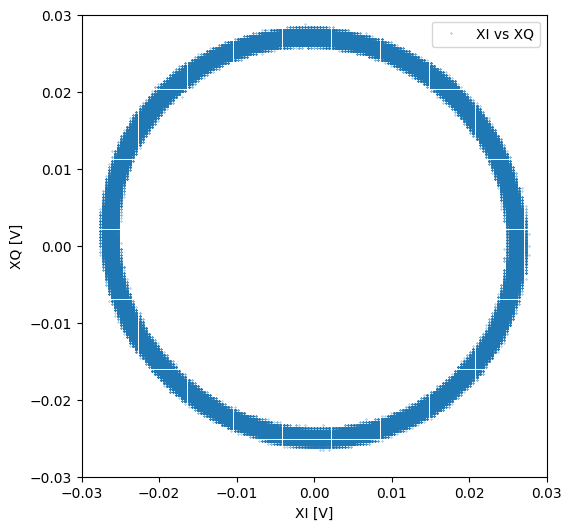

In [28]:
plt.figure(figsize=(6, 6))
plt.plot(XI_raw,XQ_raw, '.', label="XI vs XQ", markersize=0.5)
plt.xlabel("XI [V]")
plt.ylabel("XQ [V]")
# plt.title("Lissajous Curve")
plt.xlim([-0.03, 0.03])
plt.ylim([-0.03, 0.03])
plt.legend()
plt.show()


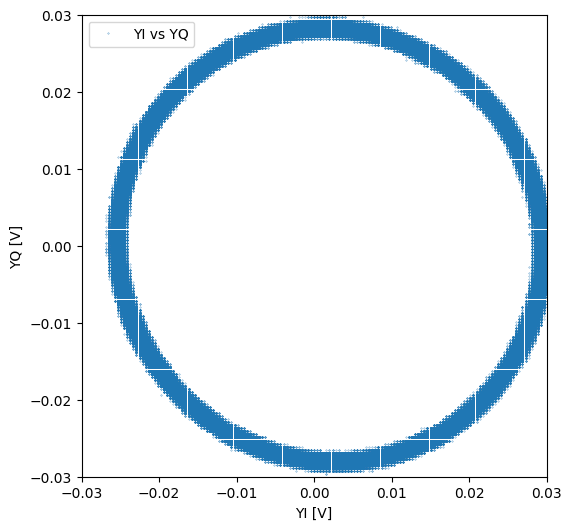

In [29]:
plt.figure(figsize=(6, 6))
plt.plot(YI_raw,YQ_raw, '.', label="YI vs YQ", markersize=0.5)
plt.xlabel("YI [V]")
plt.ylabel("YQ [V]")
# plt.title("Lissajous Curve")
plt.xlim([-0.03, 0.03])
plt.ylim([-0.03, 0.03])
plt.legend()
plt.show()


In [30]:
xc = np.mean(YI_raw)
yc = np.mean(YQ_raw)

print(xc, yc)

r = np.mean(np.sqrt((YI_raw-xc)**2 + (YQ_raw-yc)**2))

print(r)

xoffset = np.abs(xc)
yoffset = np.abs(yc)

print(np.sqrt(xoffset**2 + yoffset**2) / r)

print(np.std(YI_raw) / np.std(YQ_raw))
print(np.std(XI_raw) / np.std(XQ_raw))

0.0011705210276679845 0.0005955140316205533
0.027796204455507394
0.0472474517174879
0.9748631932265291
1.0080475123101502


In [31]:
# Load scaled voltage export
data = np.loadtxt(r"C:\Users\au617810\Downloads\PPCL_Whisper_14.11dBm_12.11+7.48dBm_20MSa_s_not_raw.Wfm.csv",delimiter=";")

In [32]:

# Split channels
XI = data[:, 0]
XQ = data[:, 1]
YI = data[:, 2]
YQ = data[:, 3]

# Compare to raw-converted values
print("XI range:", XI.min(), XI.max())
print("XQ range:", XQ.min(), XQ.max())
print("YI range:", YI.min(), YI.max())
print("YQ range:", YQ.min(), YQ.max())

# Lissajous checks
print("X std ratio:", np.std(XI) / np.std(XQ))
print("Y std ratio:", np.std(YI) / np.std(YQ))

# Offset check
xc = np.mean(YI)
yc = np.mean(YQ)

r = np.mean(np.sqrt((YI - xc)**2 + (YQ - yc)**2))

offset_fraction = np.sqrt(xc**2 + yc**2) / r

print("Center offset fraction:", offset_fraction)

XI range: -0.027667984 0.027667984
XQ range: -0.026482213 0.028853755
YI range: -0.02687747 0.030830039
YQ range: -0.029644269 0.029644269
X std ratio: 1.0080475108888685
Y std ratio: 0.9748631942598587
Center offset fraction: 0.047247453214977704


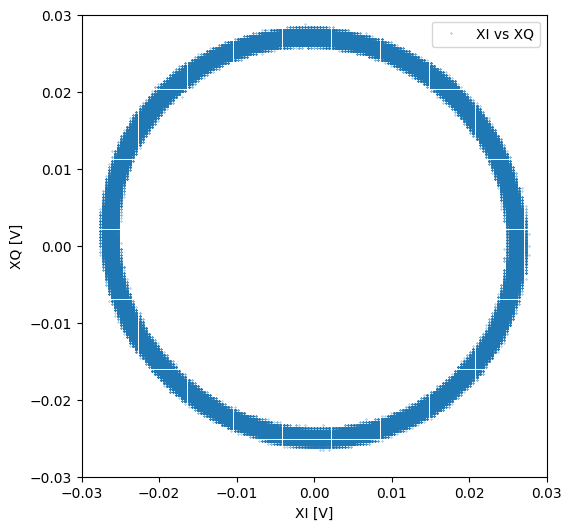

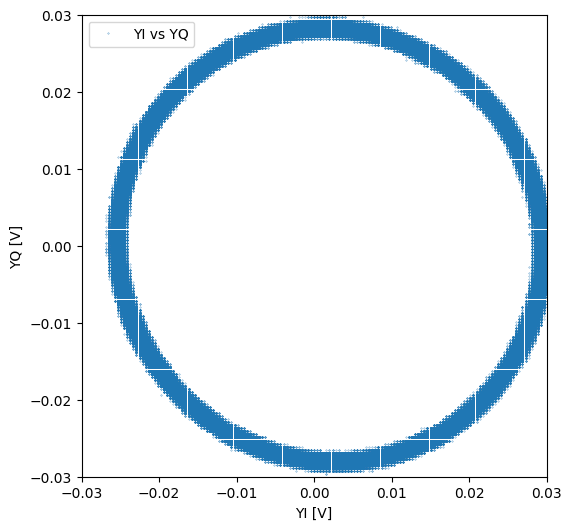

In [33]:
plt.figure(figsize=(6, 6))
plt.plot(XI,XQ, '.', label="XI vs XQ", markersize=0.5)
plt.xlabel("XI [V]")
plt.ylabel("XQ [V]")
# plt.title("Lissajous Curve")
plt.xlim([-0.03, 0.03])
plt.ylim([-0.03, 0.03])
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(YI,YQ, '.', label="YI vs YQ", markersize=0.5)
plt.xlabel("YI [V]")
plt.ylabel("YQ [V]")
# plt.title("Lissajous Curve")
plt.xlim([-0.03, 0.03])
plt.ylim([-0.03, 0.03])
plt.legend()
plt.show()

C:\Users\au617810\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\au617810\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


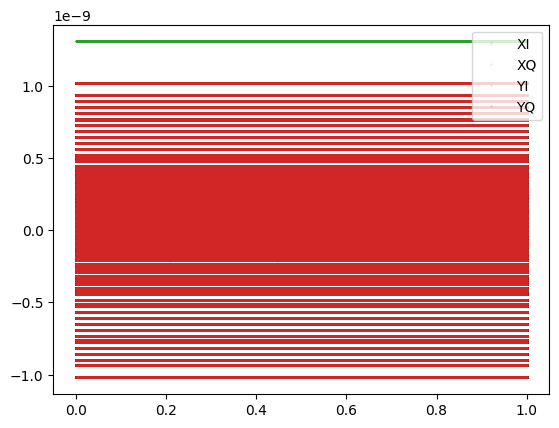

In [36]:
plt.plot(t, XI-XI_raw, '.', label="XI",alpha=0.5,markersize=0.5)
plt.plot(t, XQ-XQ_raw, '.',label="XQ",alpha=0.5,markersize=0.5)
plt.plot(t, YI-YI_raw, '.',label="YI",alpha=0.5,markersize=0.5)
plt.plot(t, YQ-YQ_raw, '.',label="YQ",alpha=0.5,markersize=0.5)
plt.legend()